# 2. Inspecting the PlatoSim3 HDF5 output files

### Setup notebook

In [1]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib inline

### Imports

In [2]:
import os
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# PlatoSim
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup
setup()

### Run a default simulation for the tutorial

In [3]:
outputDir      = os.getcwd()
outputFileName = "output_example1"
outputFile     = f"{outputDir}/{outputFileName}.hdf5"
sim = Simulation(outputFileName, outputDir=outputDir)
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True
sim.run(removeOutputFile=True)

---

## 2.1 - Inspect with SimFile

We have alread touched upon how you can use the `SimFile` class to retrieve information from the HDF5 file. Here we dive in a bit deeper and show several functionalites. We will look at the following APIs:

### API of SimFile

Request image, bias and smearing maps
```
img = simFile.getImage(<Exposure Nr>)
biasMapLeft = simFile.getBiasMapLeft(<Exposure Nr>)
biasMapRight = simFile.getBiasMapRight(<Exposure Nr>)
smearingMap = simFile.getSmearingMap(<Exposure Nr>)

subPixelImage = simFile.getSubPixelImage(<Exposure Nr>)
```

Request smaller imagettes around a star position
```
im = simFile.getImagette(11632, 9, radius = 3)
```

Request star information
```
starIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simFile.getStarCatalog()
ID, row, col, Xmm, Ymm = simFile.getStarCoordinates(<Exposure Nr> [, minVmag=<Vmag>, maxVmag=<Vmag>])
```

Request Input Parameters
```
value = simFifle.getInputParameter(<groupName>, <parameterName>)
```

Request the Flatfield maps
```
prnu = simFile.getPRNU()
irnu = simFile.getIRNU()
```

Request the PSF
```
psf = simFile.getPsf("rebinnedPSFimage")
```

Request Platform information
```
RA, dec = simFile.getPlatformPointingCoordinates()
yaw, pitch, roll = simFile.getYawPitchRoll()
```

Reloading the HDF5 file
```
simFile.reload()
```

First let's get the HDF5 file with:

In [4]:
f = SimFile(outputFileName + ".hdf5")

The bias map (from a serial prescan) can be fetched with:

In [5]:
bm = f.getBiasMapLeft(0)

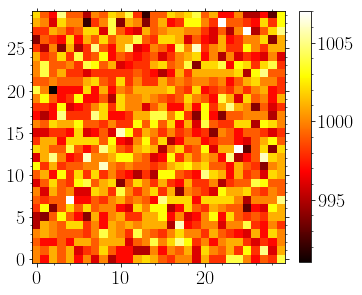

In [6]:
plt.figure(figsize=(5,5))
plt.imshow(bm, interpolation='nearest', origin='lower', cmap=cm.hot)
plt.colorbar(fraction=0.045)
plt.show()

The smearing map (from a parallel overscan) can be fetched with:

In [7]:
sm = f.getSmearingMap(0)

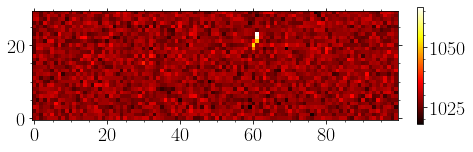

In [8]:
plt.figure(figsize=(7,7))
plt.imshow(sm, interpolation='nearest', origin='lower', cmap=cm.hot)
plt.colorbar(fraction=0.015)
plt.show()

The stellar coordinates can be fetched with:

In [9]:
starIDs = f.getStarCoordinates(9, minVmag = None, maxVmag = None)[0]
print(starIDs)

[ 41579  41663  41712  41871  41889  41932  41994  42012  42201  42287
  42477  42537 290555 290782 290903 290904 290905 291357 291474 291475
 291476 291604 291605 291657 291658 291659 292418 292419 292420 292421
 292422 292423 293168 293169]


It is also possible to fetch a smaller subfield (known as an imagette) around a given target star. Here we select starID 0, image 10, and a radius of 3 pixel:

In [10]:
imagette = f.getImagette(starIDs[0], 9, radius=3)

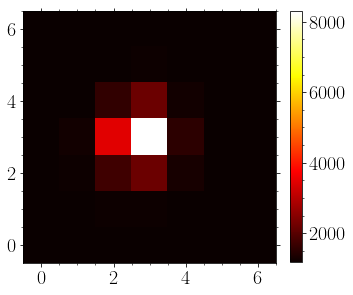

In [11]:
plt.figure(figsize=(5,5))
plt.imshow(imagette, interpolation='nearest', origin='lower', cmap=cm.hot)
plt.colorbar(fraction=0.045)
plt.show()

The PSF can also be fetched. Above we saved the high resolution PSF to file, but it is also possible to save the diffused PSF. Here we fetch the following:

In [12]:
psf = f.getPSF("HighResPSFmapCenterSubfield")

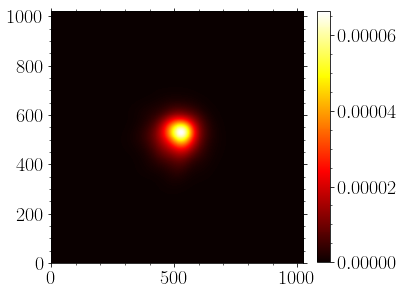

In [13]:
plt.figure(figsize=(5,5))
plt.imshow(psf, interpolation='nearest', origin='lower', cmap=cm.hot)
plt.colorbar(fraction=0.045)
plt.show()

We can also get the star catalogue by:

In [14]:
starID, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = f.getStarCatalog()
starID

array([ 40680,  40858,  40956,  40957,  41115,  41135,  41175,  41206,
        41234,  41429,  41579,  41663,  41712,  41871,  41889,  41932,
        41994,  42012,  42201,  42287,  42477,  42537, 288113, 288611,
       288884, 288885, 288886, 288887, 289337, 289338, 289385, 289386,
       289561, 289562, 289563, 289630, 289631, 289632, 290162, 290163,
       290555, 290782, 290903, 290904, 290905, 291357, 291474, 291475,
       291476, 291604, 291605, 291657, 291658, 291659, 292418, 292419,
       292420, 292421, 292422, 292423, 293168, 293169], dtype=uint32)

It is also possible to only get the coordinates of stars within a certain magnitude range `[minVmag, maxVmag]`:

In [15]:
starID, row, col, Xmm, Ymm, flux = f.getStarCoordinates(9, minVmag=10.0, maxVmag=12.0)
starID

array([41579, 41712, 41932, 41994, 42201, 42287, 42477], dtype=uint32)

We can also fetch the input observing parameters. E.g. the number of  exposures we have simulated:

In [16]:
f.getInputParameter("ObservingParameters", "NumExposures")

10

We can fetch the image dimentions and use them as extentions:

In [17]:
image      = f.getImage(9)
numRows    = f.getInputParameter("SubField", "NumRows")
numColumns = f.getInputParameter("SubField", "NumColumns")

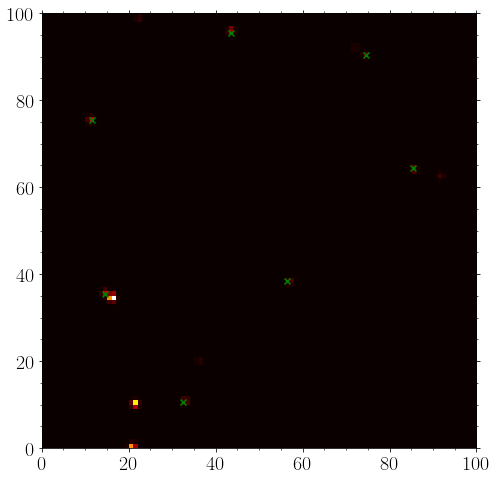

In [18]:
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(image, cmap=cm.hot, interpolation="nearest", origin='lower', 
          extent=[0, numRows, 0, numColumns])
ax.scatter(np.floor(col)+0.5, np.floor(row)+0.5, marker='x', c='g')
plt.show()

Another options is to use the build-in function `showImage` to visualize your subfield together with the stellar coordinates:

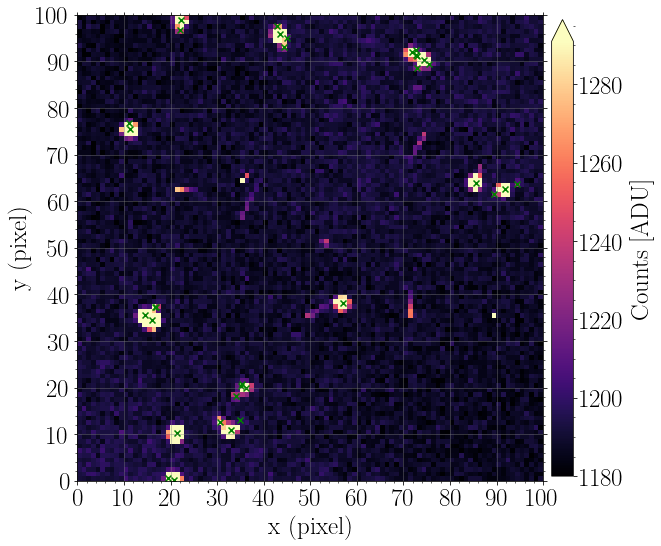

In [19]:
imageNr = 9
fig = f.showImage(imageNr, clipPercentile=1, imgScale="clip", 
                  figsize=(10,10), fontSize=25, useTitle=False,
                  showStarPositions=True, showStarIDs=False,
                  colorMap="magma", colorBar=True, showGrid=True) 

Fetch the Pixel Response Non-Uniformity (which essentially is the flat-field image):

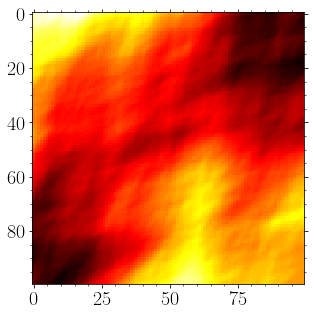

In [20]:
prnu = f.getPRNU()
plt.figure(figsize=(5,5))
plt.imshow(prnu, interpolation='nearest', cmap=cm.hot)
plt.show()

In [21]:
# Do not exist at the moment!
# irnu = f.getIRNU()
# plt.imshow(irnu, interpolation='nearest', cmap=cm.hot)

Fetch the platform jitter in either equatorial coordinates (RA, Dec) or in the spacecraft rotation angles (yaw, pitch, roll):

In [45]:
RA, Dec = f.getPlatformPointingCoordinates()

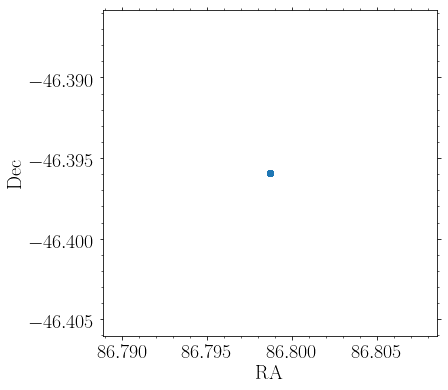

In [50]:
plt.figure(figsize=(6,6))
plt.scatter(RA, Dec)
plt.xlabel("RA")
plt.ylabel("Dec")
plt.show()

In [24]:
yaw, pitch, roll = f.getYawPitchRoll()

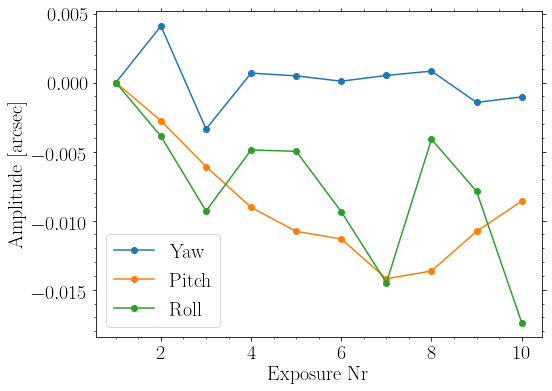

In [25]:
plt.figure(figsize=(8,6))
exp = np.arange(1,11,1)
plt.plot(exp, yaw,   '-o', label="Yaw")
plt.plot(exp, pitch, '-o', label="Pitch")
plt.plot(exp, roll,  '-o', label="Roll")
plt.xlabel("Exposure Nr")
plt.ylabel("Amplitude [arcsec]")
plt.legend()
plt.show()

---

## 2.3 - Inspect with h5py

We here show a minimal example of using `h5py` to inspect your HDF5 output file:

In [26]:
import h5py
h5file = h5py.File(outputFile, 'r')

In [27]:
im = h5file['Images/image000000']

---

## 2.3 - Inspect with h5

PlatoSim has an build-in functionality to use `h5py` to print the structure and fetch the information from the HDF5 output file:

In [28]:
from platosim.h5 import h5get, h5ls

### Function: h5ls

The function **h5ls** takes an HDF5 file object or a HDF5 group as a mandatory argument and shows the complete structure of the HDF5 file or group. Each level is indicated by the following type acronyms, and for attributes their value is shown.

[G] Group <br/>
[D] Dataset <br/>
[a] Attribute


In [29]:
h5ls(h5file['BiasMapsLeft'])

[D] /biasMap000000
[D] /biasMap000001
    ...
[D] /biasMap000009


In [30]:
h5ls(h5file['BiasMapsRight'])

[D] /biasMap000000
[D] /biasMap000001
    ...
[D] /biasMap000009


In [31]:
h5ls(h5file['InputParameters/CCD/Gain'])

[a] /AllowedDifference      15.0
[a] /     RefValueLeft      2.14
[a] /    RefValueRight      2.21
[a] /        Stability      -0.001


The full structure of the HDF5 file can be found at the end of this notebook, as it takes up too much space here.

### Function: h5get

With **h5get** you can get data out of the HDF5 file into numpy arrays or python variables. This function takes two mandatory arguments, the HDF5 file object (or group) and the 'path into the variable or dataset'.

When you specify the full path, only that variable is returned as shown in the following two commands. When you specify a partial path or just the name of the final dataset/attribute, the **h5get** function looks for all possible matches and returns an array with their values. This is illustrated further with 'ReadoutNoise'.

In [32]:
pos = h5get(h5file, "/InputParameters/CCD/Position", verbose=False)
print ("Type and value of Position: {}, {}".format(type(pos), pos))

Type and value of Position: <class 'bytes'>, b'Custom'


In [33]:
noise = h5get(h5file, "/InputParameters/CCD/ReadoutNoise", verbose=False)
print ("Type and value of ReadoutNoise: {}, {}".format(type(noise), noise))

Type and value of ReadoutNoise: <class 'numpy.float64'>, 38.7


In [34]:
h5get(h5file, "ReadoutNoise")

selection strings: ['ReadoutNoise']
matching items:
    Attribute       /InputParameters/CCD/IncludeReadoutNoise
    Attribute       /InputParameters/CCD/ReadoutNoise
    Attribute       /InputParameters/FEE/ReadoutNoise
    Attribute       /InputParameters/RandomSeeds/ReadOutNoiseSeed


[1, 38.7, 32.0, 1424949740]

In [35]:
cols = h5get(h5file, "InputParameters/CCD/NumColumns", verbose=False)
print ("Type and value of NumColumns: {}, {}".format(type(cols), cols))

Type and value of NumColumns: <class 'numpy.int32'>, 4510


In [36]:
dec = h5get(h5file, "ACS/PlatformDec", verbose=False)
ra  = h5get(h5file, "ACS/PlatformRA", verbose=False)

In [37]:
print ("Type and shape of RA : {}, {}".format(type(ra), ra.shape))
print ("Type and shape of Dec: {}, {}".format(type(dec), dec.shape))

Type and shape of RA : <class 'numpy.ndarray'>, (10,)
Type and shape of Dec: <class 'numpy.ndarray'>, (10,)


In [38]:
im = h5get(h5file,"Images/image000000", verbose=False)

In [39]:
# Print the entire HDF5 file: equivalent to specifying only the root group: h5ls(h5file['/'])
# h5ls(h5file)

---

## 2.4 - Inspect with PyTables

As a last option in this tutorial, you can also inspect and fetch information using the library `tables` (a.k.a. PyTables):

In [40]:
import tables

In [41]:
out = tables.open_file(outputFile)

In [42]:
out.root

/ (RootGroup) ''
  children := ['ACS' (Group), 'Background' (Group), 'BiasMapsLeft' (Group), 'BiasMapsRight' (Group), 'CTI' (Group), 'Cosmics' (Group), 'ExtendedGhostPositions' (Group), 'Flatfield' (Group), 'Images' (Group), 'InputParameters' (Group), 'PSF' (Group), 'PointLikeGhostPositions' (Group), 'SmearingMaps' (Group), 'StarCatalog' (Group), 'StarPositions' (Group), 'Telescope' (Group), 'ThroughputMaps' (Group), 'TransmissionEfficiency' (Group), 'Version' (Group)]

In [43]:
im = out.root.Images.image000000